# URBANopt Post-Process Setup (Path-Only)

This notebook only initializes `uo_analysis` from a single URBANopt project path.

- No Modelica loading
- No DES result processing
- Intended for cases like:
  `/Users/nlong/working/urban-analysis/esbe/esbe_2026/activity_3/coincident`

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from urbanopt_des.urbanopt_analysis import URBANoptAnalysis

sns.set_style("whitegrid")
graph_size = (8, 4)

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
# Single input: can be either a URBANopt project dir or a scenario run dir.
# Example outside this repo: /Users/nlong/working/junk
input_path = Path("/Users/nlong/working/junk").expanduser()

# Optional override. If None, choose baseline_scenario when available, else first run folder.
scenario_name = None

if not input_path.exists():
    raise FileNotFoundError(f"Input path does not exist: {input_path}")

year = 2017

# Resolve whether input_path is a project directory or a scenario directory.
if (input_path / "run").exists():
    uo_project_dir = input_path
    run_dir = uo_project_dir / "run"
elif input_path.parent.name == "run":
    uo_project_dir = input_path.parent.parent
    run_dir = uo_project_dir / "run"
    scenario_name = input_path.name
else:
    raise ValueError(
        "Input path must be a URBANopt project dir (contains run/) or a scenario dir under run/."
    )

if not run_dir.exists():
    raise FileNotFoundError(f"Run directory not found: {run_dir}")

if scenario_name is None:
    if (run_dir / "baseline_scenario").exists():
        scenario_name = "baseline_scenario"
    else:
        scenario_dirs = sorted([p for p in run_dir.iterdir() if p.is_dir()])
        if not scenario_dirs:
            raise FileNotFoundError(f"No scenario directories found in: {run_dir}")
        scenario_name = scenario_dirs[0].name

scenario_results_dir = run_dir / scenario_name
if not scenario_results_dir.exists():
    raise FileNotFoundError(f"Scenario directory not found: {scenario_results_dir}")

# Auto-discover a project geojson in the project directory.
geojson_candidates = sorted(uo_project_dir.glob("class_project*.json"))
if not geojson_candidates:
    geojson_candidates = sorted(uo_project_dir.glob("*.json"))
if not geojson_candidates:
    raise FileNotFoundError(f"No project GeoJSON found in: {uo_project_dir}")

project_geojson_filename = geojson_candidates[0]
analysis_dir = uo_project_dir

# Output directory for saved plots and summary CSVs
results_summary_dir = scenario_results_dir / "_results_summary"
results_summary_dir.mkdir(parents=True, exist_ok=True)

# Make it clear to check these values and make sure they are the right files/lociations
# before moving on to the analysis and plotting steps

print("=== Configuration (BE SURE TO REVIEW)===")
print(f"Input path: {input_path}")
print(f"URBANopt project dir: {uo_project_dir}")
print(f"Scenario: {scenario_name}")
print(f"GeoJSON: {project_geojson_filename}")
print(f"Results dir: {scenario_results_dir}")
print(f"Results summary dir: {results_summary_dir}")

=== Configuration (BE SURE TO REVIEW)===
Input path: /Users/nlong/working/junk
URBANopt project dir: /Users/nlong/working/junk
Scenario: baseline_scenario
GeoJSON: /Users/nlong/working/junk/class_project_coincident.json
Results dir: /Users/nlong/working/junk/run/baseline_scenario
Results summary dir: /Users/nlong/working/junk/run/baseline_scenario/_results_summary


In [ ]:
# Create URBANopt analysis object and load URBANopt results only
uo_analysis = URBANoptAnalysis(project_geojson_filename, analysis_dir, year)

uo_analysis.add_urbanopt_results(uo_project_dir, scenario_name)

# Some buildings may not have load-export files; continue with a warning.
try:
    uo_analysis.urbanopt.process_load_results(uo_analysis.geojson.get_building_ids())
except Exception as exc:
    warnings.warn(
        f"Skipping missing building load exports for now: {exc}", RuntimeWarning
    )

uo_analysis.urbanopt.create_aggregations(uo_analysis.geojson.get_building_ids())
uo_analysis.urbanopt.save_dataframes()
uo_analysis.urbanopt.display_name = "Non-Connected"

geojson_building_ids = uo_analysis.geojson.get_building_ids()

# Keep additional variable list minimal and robust.
other_vars_to_gather = []

# There are no Modelica results in this case, but run the function regardless. 
uo_analysis.resample_and_convert_modelica_results([], other_vars_to_gather)
uo_analysis.save_modelica_variables()

# Save a copy of URBANopt OpenStudio results in the analysis directory.
uo_analysis.save_urbanopt_results_in_modelica_paths()

# Create combined dataframes between Modelica and OpenStudio.
uo_analysis.combine_modelica_and_openstudio_results()

# Load actual data and create aggregations.
uo_analysis.resample_actual_data()

# Save combined data frames for testing.
uo_analysis.save_dataframes("min_60_with_buildings")

# Aggregations across columns.
uo_analysis.create_modelica_aggregations()

# Roll up to monthly, annual, etc.
uo_analysis.create_rollups()

# Create building summary tables.
uo_analysis.create_building_summaries()

# Save resulting dataframes (including carbon metrics if present).
uo_analysis

URBANopt analysis name baseline_scenario
Reading building characteristics for 1
Processing building time series results 1
Reading building characteristics for 2
Processing building time series results 2
Reading building characteristics for 3
Processing building time series results 3
Reading building characteristics for 4
Processing building time series results 4
Reading building characteristics for 5
Processing building time series results 5
Reading building characteristics for 6
Processing building time series results 6
Reading building characteristics for 7
Processing building time series results 7
Reading building characteristics for 8
Processing building time series results 8
Reading building characteristics for 9
Processing building time series results 9
Reading building characteristics for 10
Processing building time series results 10
Reading building characteristics for 11
Processing building time series results 11
Reading building characteristics for 12
Processing building time

In [4]:
uo_analysis.calculate_all_grid_metrics()
# display the grid metric for one of the analysis
# display(uo_analysis.modelica['controlled'].grid_metrics_annual)

# still need to add in utility costs
# uo_analysis.calculate_utility_costs()

# save the dataframes, grid metrics only
uo_analysis.save_dataframes(["grid_metrics_daily", "grid_metrics_annual"])

# Combine all the results of the analyses for comparison
uo_analysis.create_summary_results()
uo_analysis.save_dataframes(["grid_summary", "end_use_summary"])
# create a mapping for the names
analysis_name_mappings = uo_analysis.display_name_mappings()

# Create building level results for the UO results
buildings_df = uo_analysis.create_building_level_results()
buildings_df.to_csv(
    uo_analysis.urbanopt.scenario_output_path / "building_metrics_annual.csv",
    index=True,
)
print(
    f"Saved to {uo_analysis.urbanopt.scenario_output_path / 'building_metrics_annual.csv'}"
)

display(buildings_df)

Saved to /Users/nlong/working/junk/run/baseline_scenario/output/building_metrics_annual.csv


,Metric,Unit,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,Property Type,,Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],...,Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type],Unknown [not in GeoJSON Property Type]
1,Building Type,,Enclosed mall,Lodging,Office,Office,Office,Office,Office,Office,...,Single-Family Detached,Single-Family Detached,Single-Family Detached,Single-Family Detached,Single-Family Detached,Food sales,Food sales,Food sales,Food sales,Education
2,Total Natural Gas,Wh,442389428.966121,1926158591.883305,235743973.48844,311244946.763434,215178733.736841,169405566.306151,166262433.51291,159277247.097362,...,0.0,0.0,0.0,0.0,0.0,883967476.825086,277163671.678464,288001516.929937,540745222.068521,816771712.440863
3,Total Electricity,Wh,1107345347.954498,1410995611.367892,171565064.088703,405758357.370559,319465632.52224,115292855.424324,112352511.399185,106162356.198257,...,36675696.958967,34219042.231357,33269052.417459,33056448.315059,33394666.5951,1179308268.167891,289868633.091375,310718688.269689,690700657.885936,646895135.163993
4,Total Energy,Wh,1549734776.920619,3337154203.251197,407309037.577143,717003304.133993,534644366.259081,284698421.730475,278614944.912095,265439603.295619,...,36675696.958967,34219042.231357,33269052.417459,33056448.315059,33394666.5951,2063275744.992977,567032304.76984,598720205.199626,1231445879.954457,1463666847.604856
5,Gross Floor Area,m2,8193.096467,11780.239639,2006.899086,5193.526754,4052.482225,1335.895317,1297.281289,1228.976474,...,896.655746,820.037911,785.125228,775.091583,790.337121,4264.329186,1120.296992,1132.591459,2409.035177,6814.265552
6,Gross Floor Area,ft2,88157.717982,126755.378511,21594.234161,55882.347876,43604.708737,14374.23361,13958.746667,13223.786864,...,9648.015824,8823.607925,8447.947451,8339.98543,8504.027425,45884.182046,12054.395637,12186.684096,25921.218509,73321.497337
7,Building EUI,kWh/m2,189.151291,283.284068,202.954419,138.057112,131.930095,213.11432,214.768337,215.984284,...,40.902762,41.72861,42.374199,42.648442,42.253699,483.845326,506.144628,528.628572,511.17804,214.794513
8,Building EUI,kBtu/ft2,59.982406,89.833169,64.359562,43.779758,41.836799,67.581403,68.105914,68.491507,...,12.970813,13.232701,13.437426,13.524392,13.399213,153.433828,160.505235,167.635195,162.101397,68.114215


### Simple Graphs

In [5]:
# end use names and colors. The names have to match what is in the end_use_summary results dataframe
energy_end_use_rows = {
    "Interior Lighting": "#FFFFCC",
    "Exterior Lighting": "lightblue",
    "Plug Loads": "brown",
    "Building Cooling": "blue",
    "District Cooling": "blue",
    "District Heating": "orange",
    "Building Heating": "orange",
    "Building Fans": "lightgray",
    "Building Pumps": "lightblue",
    "Building Heat Rejection": "royalblue",
    "Building Water Systems": "#FFBB78",
    "ETS Pump Total": "lightgreen",
    "ETS Heat Pump": "gold",
    "Sewer Pump": "darkgray",
    "GHX Pump": "darkgreen",
    "Distribution Pump": "darkblue",
}

Saved plot to /Users/nlong/working/junk/run/baseline_scenario/_results_summary/end_use_summary_non_connected.csv


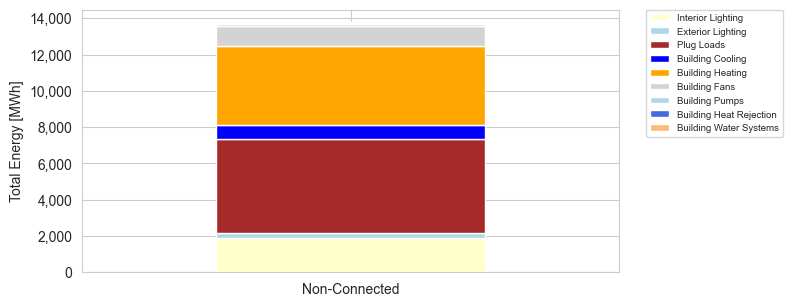

In [6]:
# Plot only the Non-Connected end uses
# drop all columns except "Units" and "Non-Connected"
df_to_plot = uo_analysis.end_use_summary.copy()
columns_to_drop = [col for col in df_to_plot.columns if col not in ["Non-Connected"]]
df_to_plot = df_to_plot.drop(columns=columns_to_drop)

# remove the rows where the "Non-Connected" values are zero
df_to_plot = df_to_plot[df_to_plot["Non-Connected"] > 0]
# copy the energy_end_use_rows and remove the ones that are not in the df_to_plot
end_use_rows_sub = energy_end_use_rows.copy()
rows_with_data = df_to_plot.index.tolist()
end_use_rows_sub = {
    key: value for key, value in end_use_rows_sub.items() if key in rows_with_data
}

df_to_plot = df_to_plot.T / 1e6
df_to_plot = df_to_plot[end_use_rows_sub.keys()]

# save off the data for sending
df_to_plot.to_csv(results_summary_dir / "end_use_summary_non_connected.csv")
print(f"Saved plot to {results_summary_dir / 'end_use_summary_non_connected.csv'}")

# plot the end use summary with the updated colors
df_to_plot.plot.bar(
    figsize=graph_size, stacked=True, color=end_use_rows_sub.values()
)  # title=f"Analysis Summary"
plt.legend(
    fontsize="x-small", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0
)
plt.tight_layout()
plt.subplots_adjust(left=0.1)  # fix the left axis to show the full text
plt.ylabel("Total Energy [MWh]")
# rotate labels on xaxis
plt.xticks(rotation=0)
# add thousands separator to y-axis
plt.gca().get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, _loc: f"{int(x):,}")
)

output_name = results_summary_dir / "bar_end_use_summary_all.png"
plt.savefig(output_name, dpi=300)
plt.show()

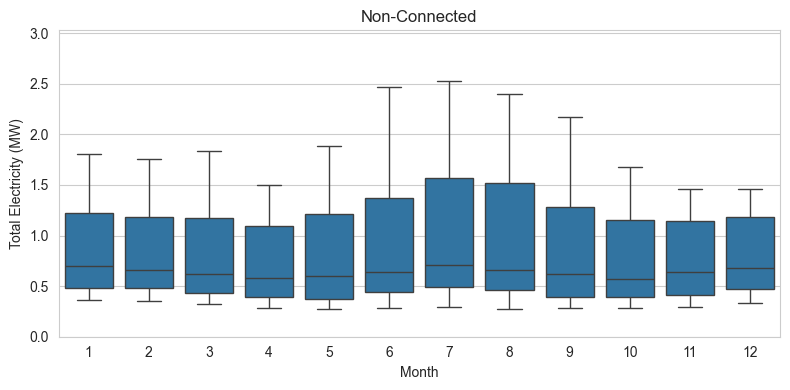

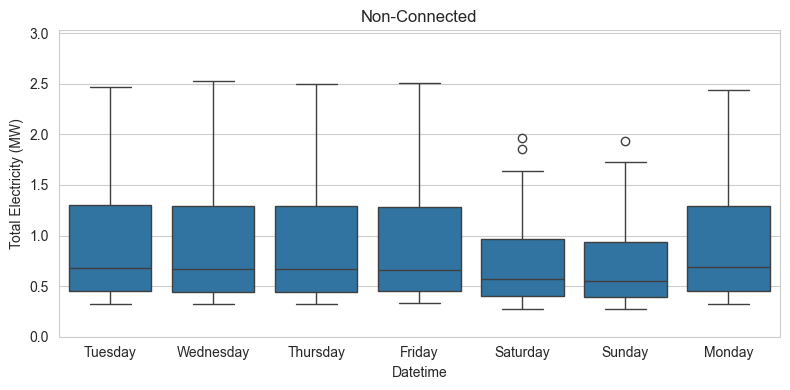

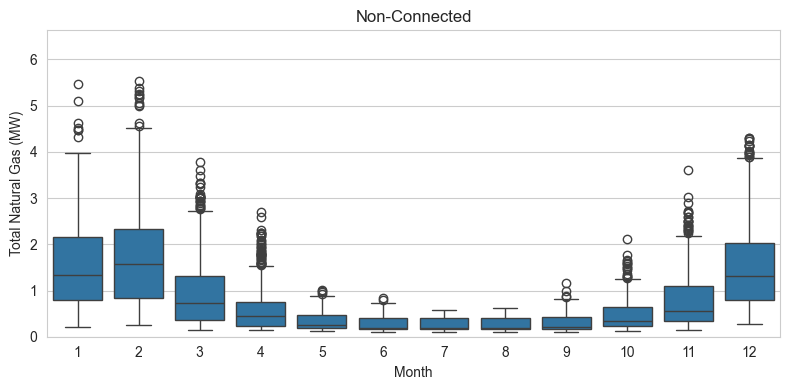

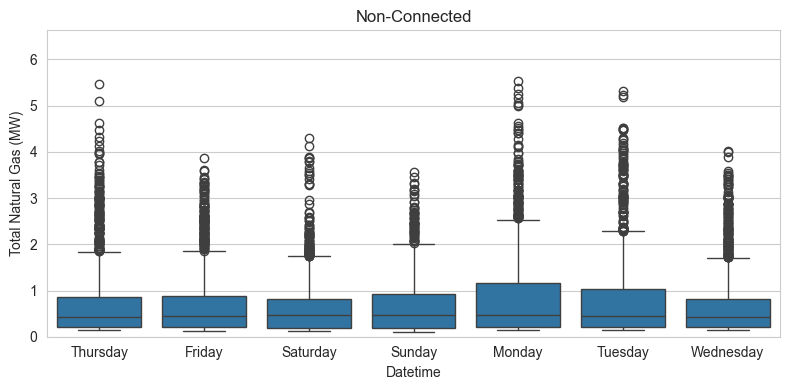

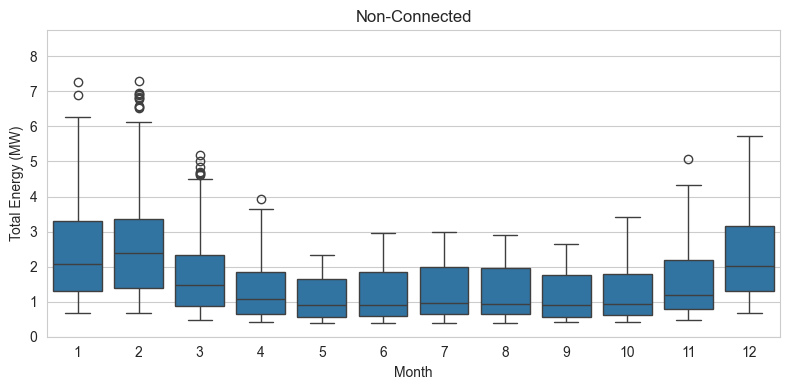

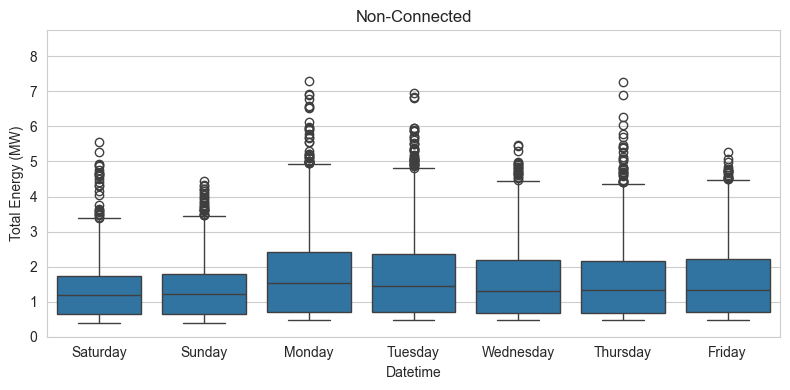

In [7]:
# seasonal plots - list of vars to plat
for analysis_name in ["Non-Connected", *list(uo_analysis.modelica.keys())]:
    vars_to_plot = [
        "Total Electricity",
        "Total Natural Gas",
        # "Total Thermal Cooling Energy",
        # "Total Thermal Heating Energy",
        # "District Loop Energy",
        "Total Energy",
    ]

    if analysis_name == "Non-Connected":
        df_season = uo_analysis.urbanopt.data
    else:
        df_season = uo_analysis.modelica[analysis_name].min_60_with_buildings

    for var_to_plot in vars_to_plot:
        str_analysis_name = analysis_name.lower().replace(" ", "_")
        str_vars_to_plot = var_to_plot.lower().replace(" ", "_")

        # skip the plot if all the data are zero
        if df_season[var_to_plot].sum() == 0:
            print(
                f"Skipping plot for {analysis_name} - {var_to_plot} because the sum is zero"
            )
            continue

        # remove the first two data of the data, the warm up peak is annoying!
        df_season = df_season.iloc[48:]

        # Monthly consumption (in MWh)
        var_y_min = df_season[var_to_plot].min() / 1e6
        var_y_max = df_season[var_to_plot].max() / 1e6

        # extend past the min / max by 20% for plotting
        # if var_y_min + var_y_max is < 0, then extend the min and max in opposite directions
        if var_y_min + var_y_max < 0:
            var_y_min = var_y_min * 1.2
            var_y_max = var_y_max * 0.8
        else:
            var_y_min = var_y_min * 0.8
            var_y_max = var_y_max * 1.2

        # if the min or max is so close to 0, then just make zero
        if abs(var_y_min) < 1 and abs(var_y_max) < 1:
            # do nothing
            pass
        else:
            if abs(var_y_min) < 1:
                var_y_min = 0
            if abs(var_y_max) < 1:
                var_y_max = 0

        _fig, ax = plt.subplots(figsize=graph_size)
        sns.boxplot(data=df_season / 1e6, x=df_season.index.month, y=var_to_plot, ax=ax)
        ax.set_ylabel(f"{var_to_plot} (MW)")
        # ax.set_title(f"{analysis_name_mappings[analysis_name]} - {var_to_plot}")
        ax.set_xlabel("Month")
        ax.set_ylim(var_y_min, var_y_max)
        plt.title(analysis_name)
        plt.tight_layout()
        output_name = (
            results_summary_dir
            / f"monthly_boxplot_{str_vars_to_plot}_{str_analysis_name}.png"
        )
        plt.savefig(output_name, dpi=300)

        # Weekday consumption
        _fig, ax = plt.subplots(figsize=graph_size)
        sns.boxplot(
            data=df_season / 1e6, x=df_season.index.day_name(), y=var_to_plot, ax=ax
        )
        ax.set_ylabel(f"{var_to_plot} (MW)")
        # ax.set_title(f"{analysis_name_mappings[analysis_name]} - {var_to_plot}")
        # ax.set_xlabel('Weekday')
        ax.set_ylim(var_y_min, var_y_max)
        plt.title(analysis_name)
        plt.tight_layout()
        output_name = (
            results_summary_dir
            / f"weekday_boxplot_{str_vars_to_plot}_{str_analysis_name}.png"
        )
        plt.savefig(output_name, dpi=300)

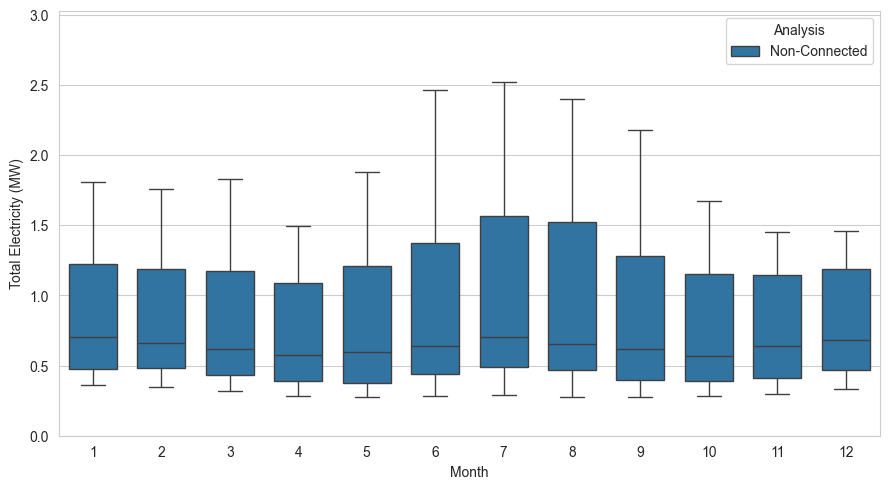

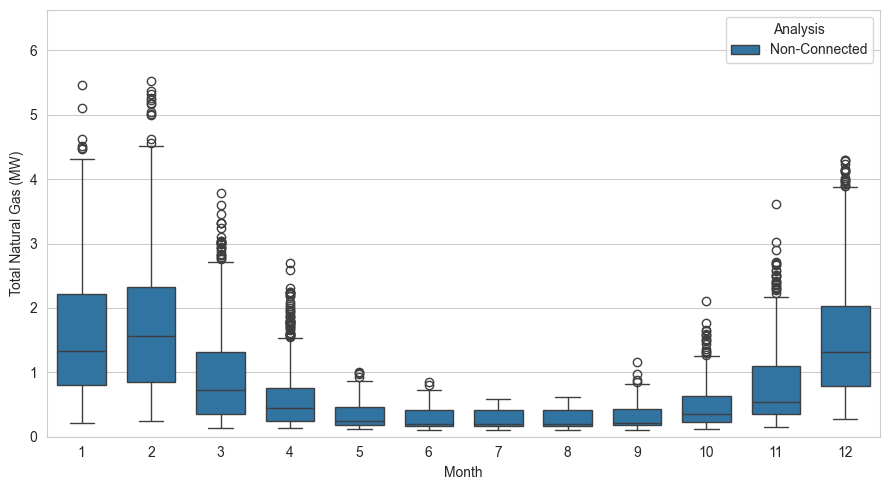

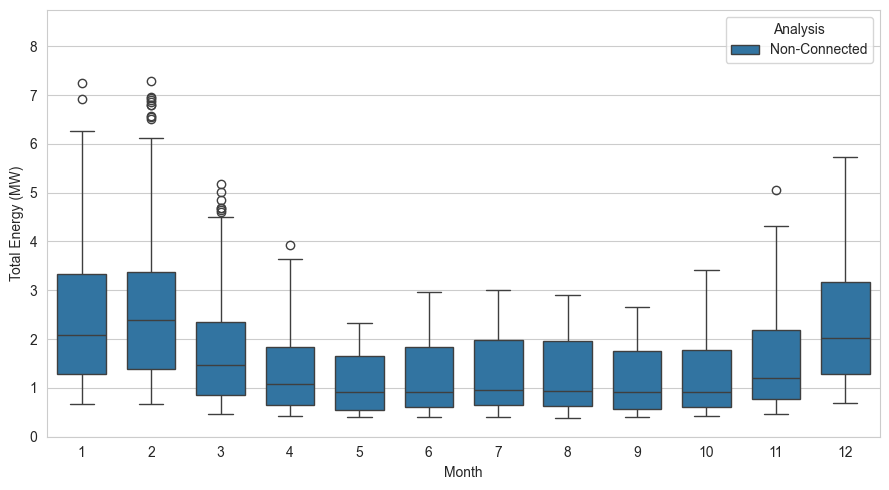

In [8]:
# Combined boxplots for energy usage monthly
import pandas as pd

# seasonal plots - list of vars to plat
for analysis_name in ["Non-Connected", *list(uo_analysis.modelica.keys())]:
    vars_to_plot = [
        "Total Electricity",
        "Total Natural Gas",
        # "Total Thermal Cooling Energy",
        # "Total Thermal Heating Energy",
        # "District Loop Energy",
        "Total Energy",
    ]

for var_to_plot in vars_to_plot:
    combined_df = []

    for analysis_name in ["Non-Connected", *list(uo_analysis.modelica.keys())]:
        if analysis_name == "Non-Connected":
            df_season = uo_analysis.urbanopt.data.copy() / 1e6
            df_season["Analysis"] = analysis_name
        else:
            df_season = (
                uo_analysis.modelica[analysis_name].min_60_with_buildings.copy() / 1e6
            )
            df_season["Analysis"] = uo_analysis.modelica[analysis_name].display_name

        df_season = df_season.iloc[48:]  # Remove initial warm-up peak
        combined_df.append(df_season)

    combined_df = pd.concat(combined_df)

    # Monthly consumption
    _fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(
        data=combined_df,
        x=combined_df.index.month,
        y=var_to_plot,
        hue="Analysis",
        dodge=True,
        width=0.7,
        ax=ax,
    )

    var_y_min = 0
    var_y_max = combined_df[var_to_plot].max() * 1.2

    ax.set_ylabel(f"{var_to_plot} (MW)")
    ax.set_xlabel("Month")
    ax.set_ylim(var_y_min, var_y_max)
    # plt.legend(title="Analysis")
    plt.tight_layout()
    plt.savefig(
        results_summary_dir
        / f"monthly_boxplot_{var_to_plot.lower().replace(' ', '_')}.png",
        dpi=300,
    )
    plt.show()


# TODO: And annual boxplots???

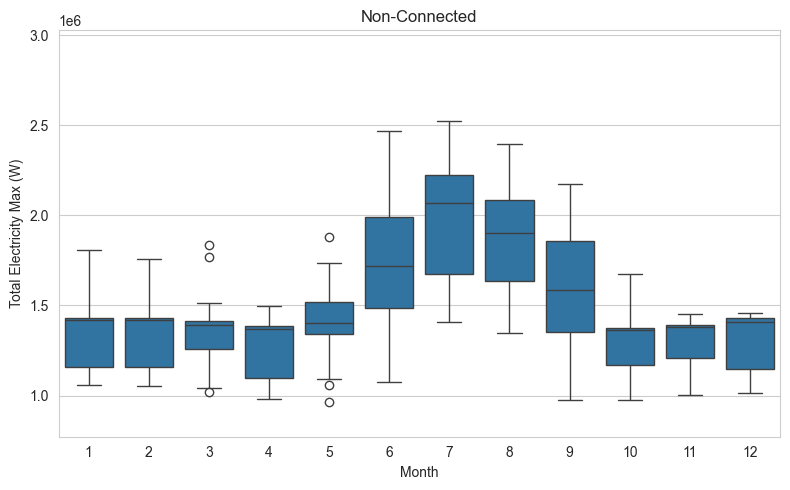

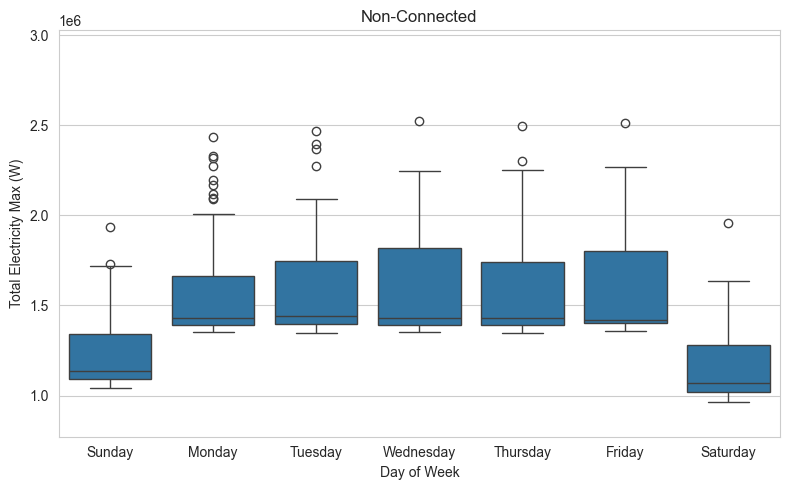

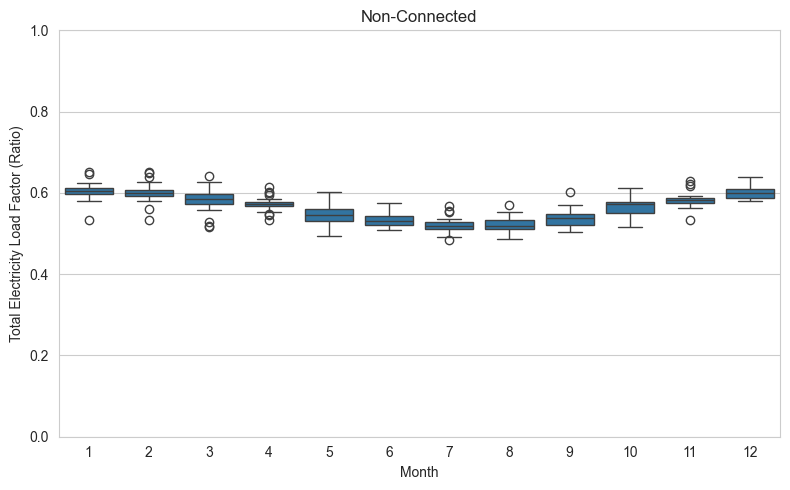

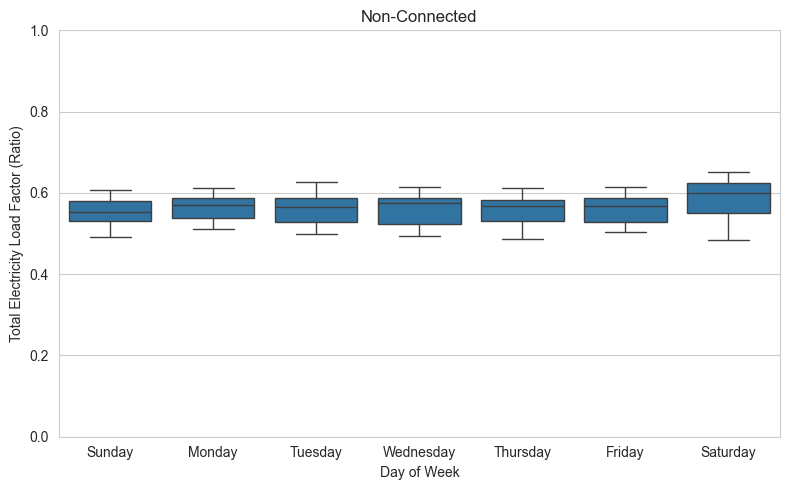

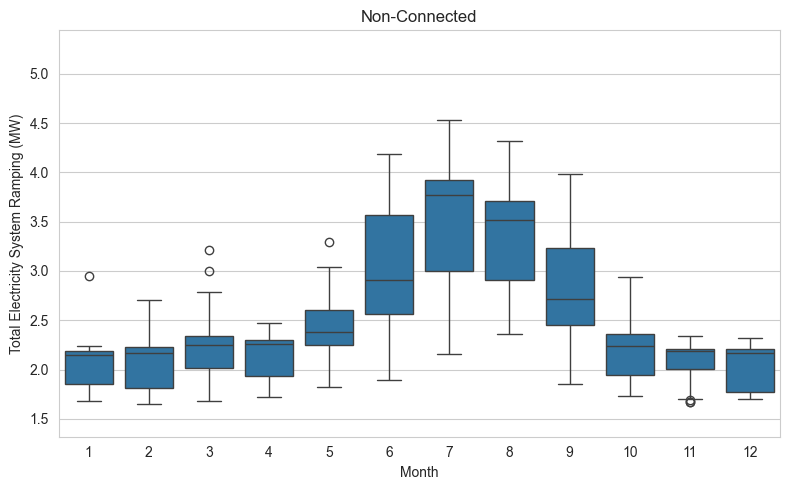

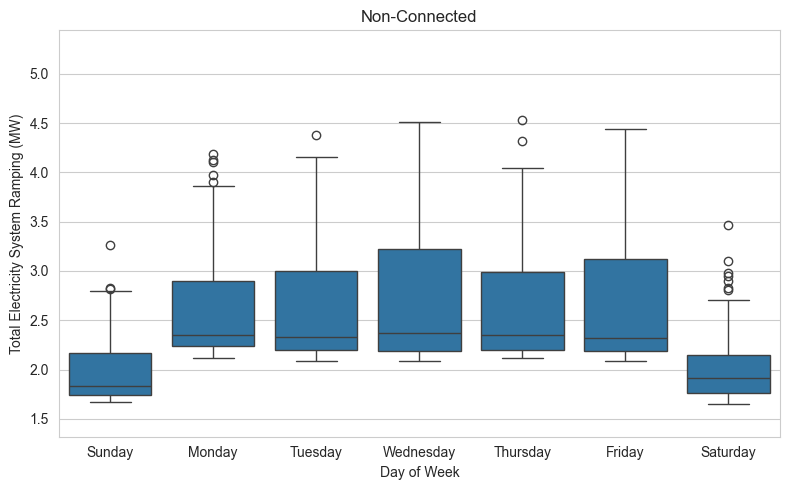

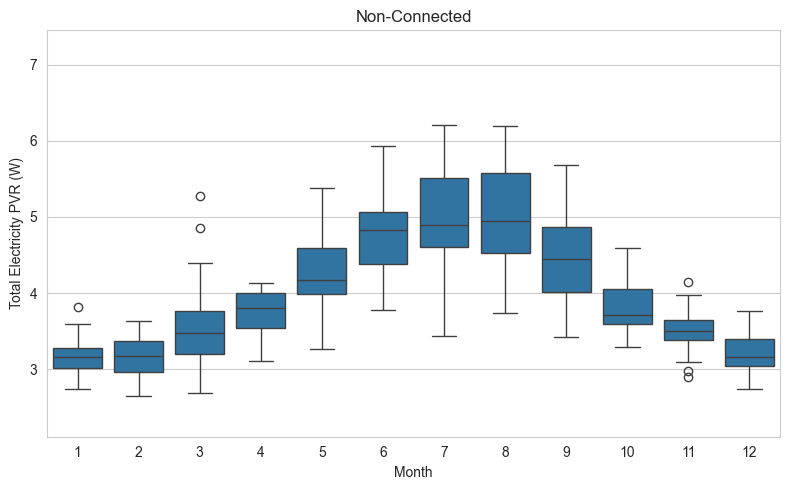

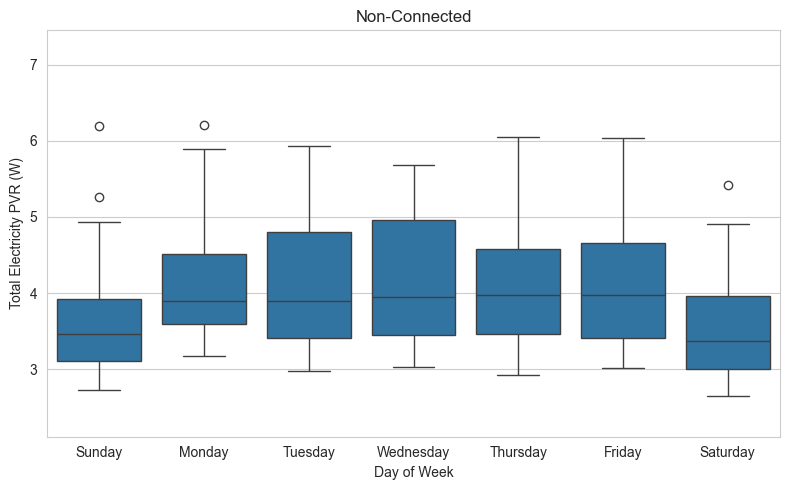

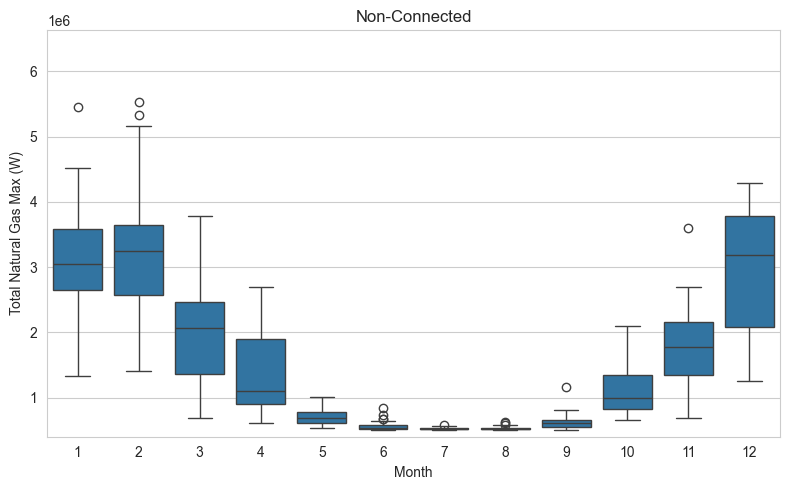

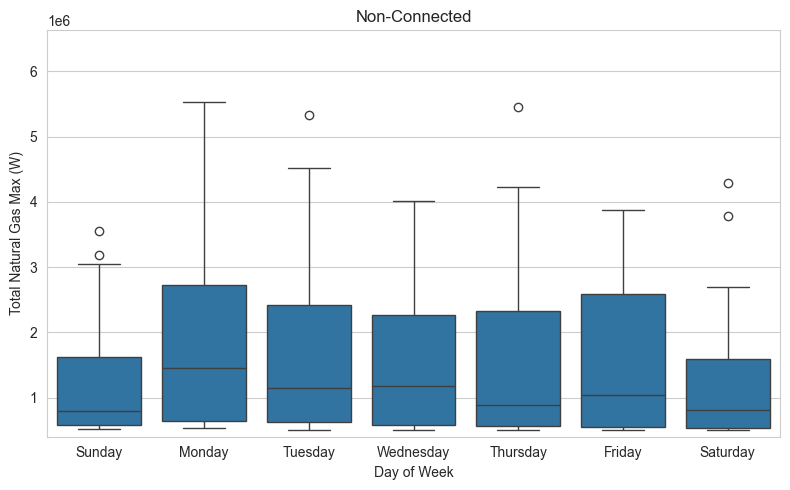

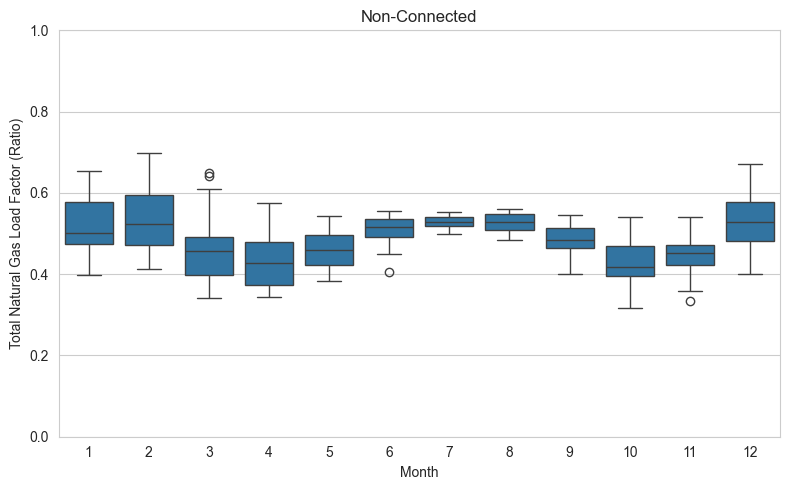

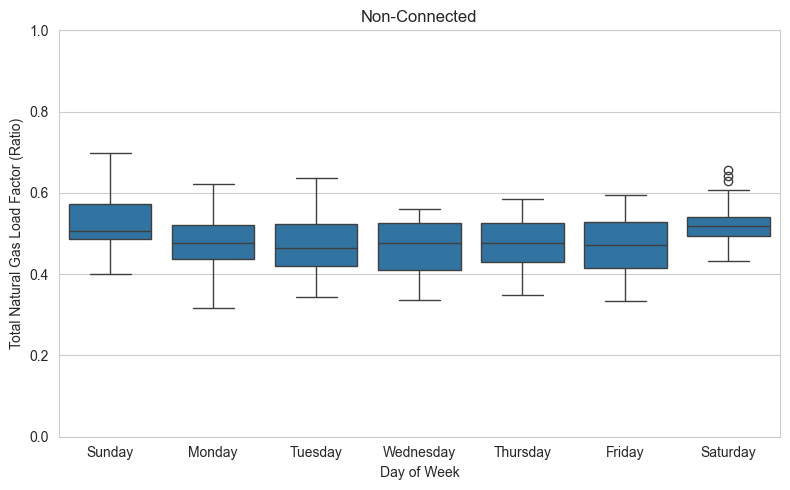

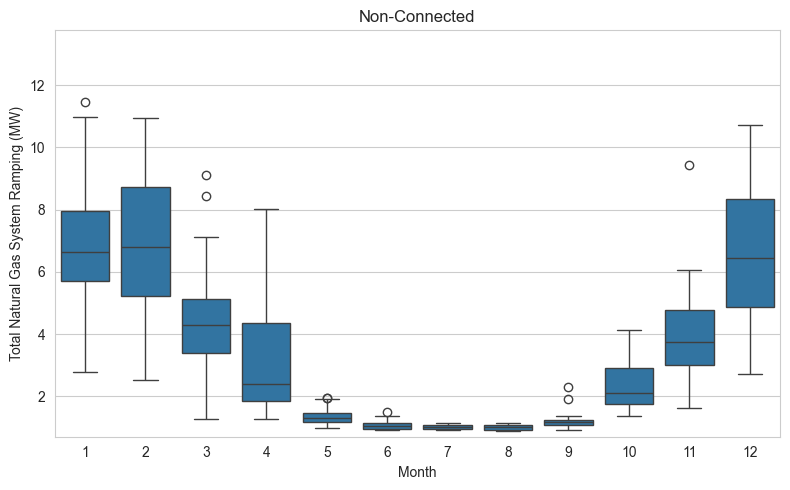

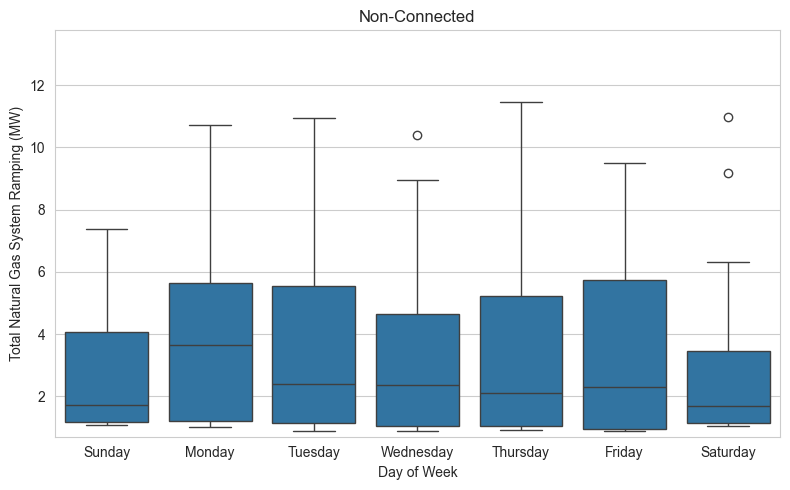

In [9]:
# daily box plots of grid vars
vars_to_plot = [
    "Total Electricity Max",
    "Total Electricity Load Factor",
    "Total Electricity System Ramping",
    "Total Electricity PVR",
    # "Total Building Natural Gas Max",
    # "Total Building Natural Gas Load Factor",
    "Total Natural Gas Max",
    "Total Natural Gas Load Factor",
    "Total Natural Gas System Ramping",
    # 'Total Thermal Cooling Energy Load Factor',
    # 'Total Thermal Heating Energy Load Factor',
    # 'Total Thermal Cooling Energy System Ramping',
    # 'Total Thermal Heating Energy System Ramping',
    # 'District Loop Energy Load Factor',
    # 'District Loop Energy System Ramping',
]

for analysis_name in ["Non-Connected", *list(uo_analysis.modelica.keys())]:
    if analysis_name == "Non-Connected":
        df_box = uo_analysis.urbanopt.grid_metrics_daily
    else:
        df_box = uo_analysis.modelica[analysis_name].grid_metrics_daily

    for var_to_plot in vars_to_plot:
        y_min = df_box[var_to_plot].min() * 0.8
        y_max = df_box[var_to_plot].max() * 1.2
        # Monthly consumption
        _fig, ax = plt.subplots(figsize=(8, 5))
        sns.boxplot(data=df_box, x=df_box.index.month, y=var_to_plot, ax=ax)
        if "System Ramping" in var_to_plot:
            ax.set_ylabel(f"{var_to_plot} (MW)")
            save_name = "system_ramping"
            # grab the y_max from the data and round to the ceiling
        elif "Load Factor" in var_to_plot:
            ax.set_ylabel(f"{var_to_plot} (Ratio)")
            save_name = "load_factor"
            y_min = 0
            y_max = 1
        else:
            ax.set_ylabel(f"{var_to_plot} (W)")
            save_name = "electricity"
        # ax.set_title(f"Daily {var_to_plot} for {analysis_name_mappings[analysis_name]}")
        ax.set_xlabel("Month")

        var_to_plot_str = var_to_plot.lower().replace(" ", "_")
        if y_max:
            if y_min:
                ax.set_ylim(y_min, y_max)
            else:
                ax.set_ylim(0, y_max)
        plt.title(analysis_name)
        plt.tight_layout()
        plt.savefig(
            results_summary_dir
            / f"monthly_grid_metric_{var_to_plot_str}_{analysis_name}.png",
            dpi=300,
        )
        plt.show()

        # Weekday consumption
        y_min = df_box[var_to_plot].min() * 0.8
        y_max = df_box[var_to_plot].max() * 1.2
        _fig, ax = plt.subplots(figsize=(8, 5))
        sns.boxplot(
            data=df_box, x=df_box.index.day_name(), y=var_to_plot, ax=ax
        )  # ,  order=['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
        # resort the data to be sunday first
        if "System Ramping" in var_to_plot:
            ax.set_ylabel(f"{var_to_plot} (MW)")
            save_name = "system_ramping"
        elif "Load Factor" in var_to_plot:
            ax.set_ylabel(f"{var_to_plot} (Ratio)")
            save_name = "load_factor"
            y_min = 0
            y_max = 1
        else:
            ax.set_ylabel(f"{var_to_plot} (W)")
            save_name = "electricity"
        ax.set_xlabel("Day of Week")

        var_to_plot_str = var_to_plot.lower().replace(" ", "_")
        if y_max:
            if y_min:
                ax.set_ylim(y_min, y_max)
            else:
                ax.set_ylim(0, y_max)
        plt.title(analysis_name)
        plt.tight_layout()
        plt.savefig(
            results_summary_dir
            / f"weekday_grid_metric_{var_to_plot_str}_{analysis_name}.png",
            dpi=300,
        )
        plt.show()

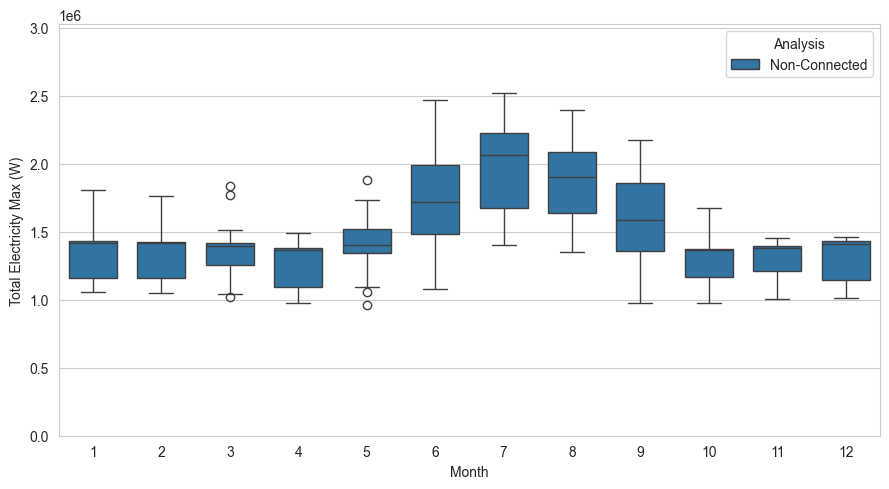

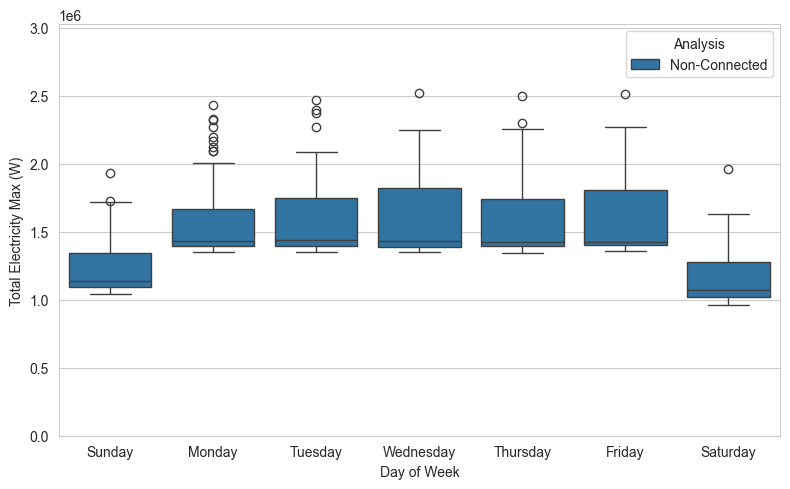

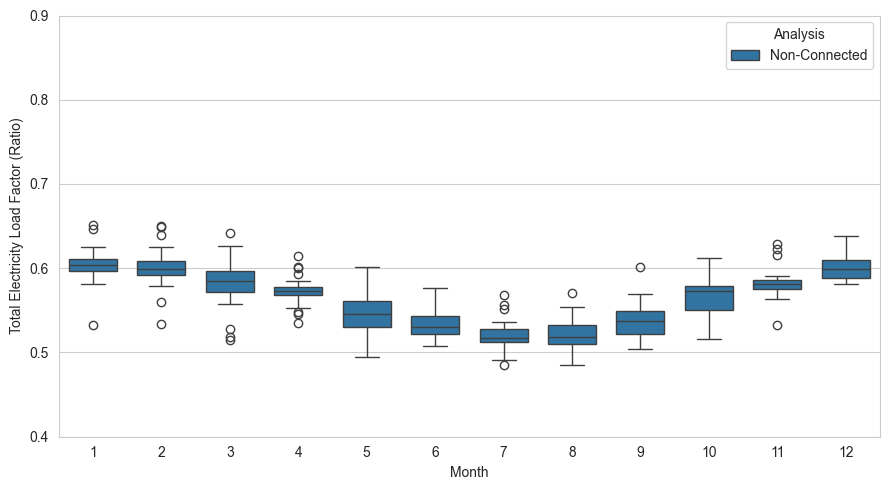

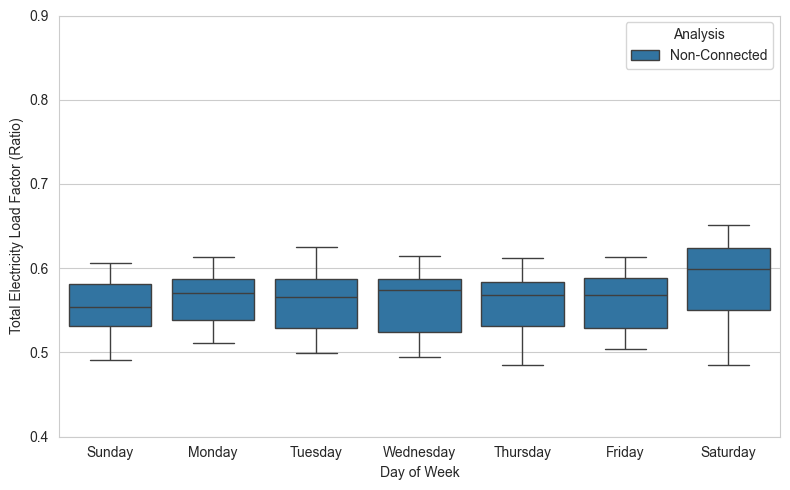

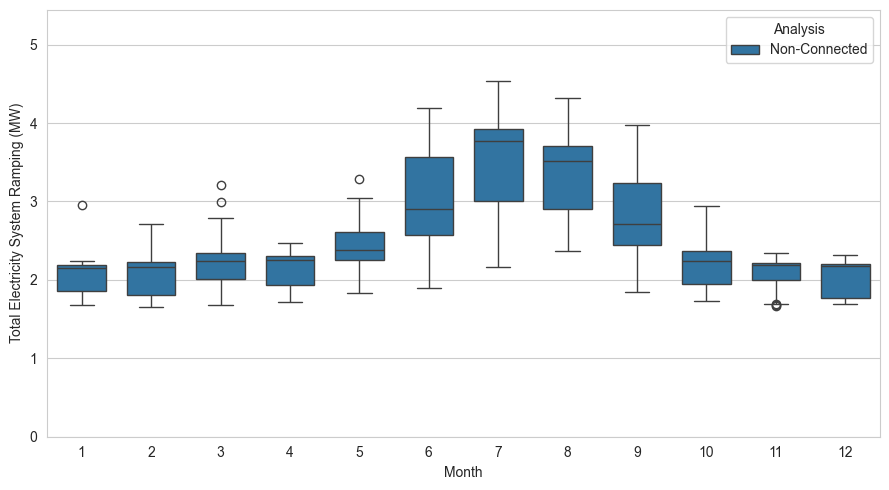

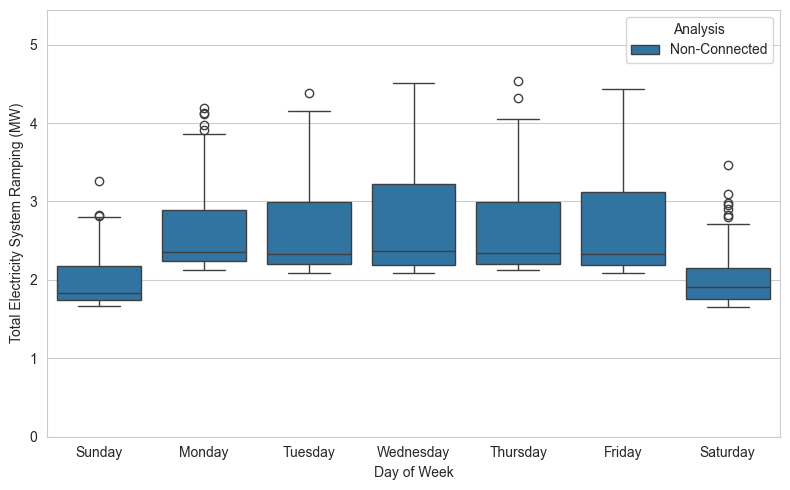

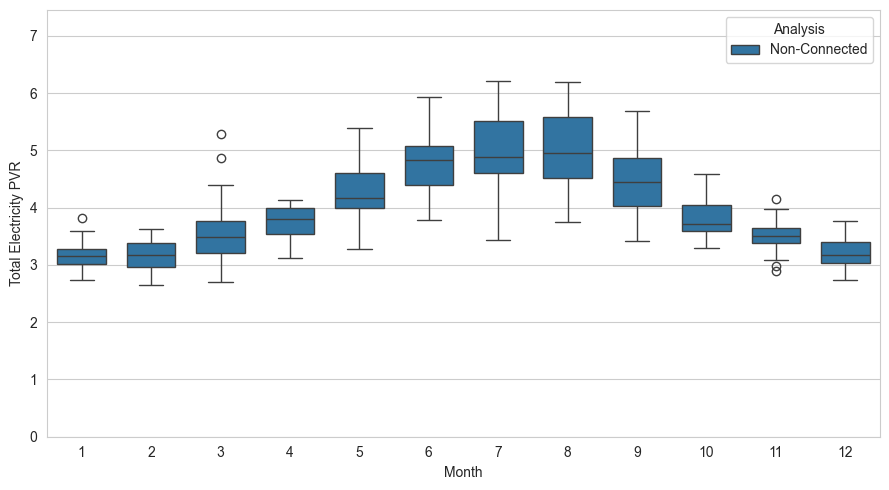

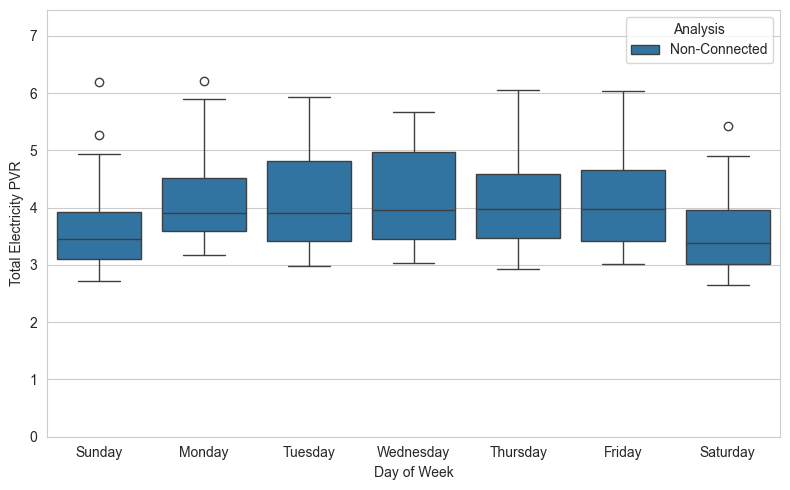

In [10]:
# Creating combined boxplots
import pandas as pd

# daily box plots of grid vars
vars_to_plot = [
    "Total Electricity Max",
    "Total Electricity Load Factor",
    "Total Electricity System Ramping",
    "Total Electricity PVR",
    # "Total Building Natural Gas Max",
    # "Total Building Natural Gas Load Factor",
]
for var_to_plot in vars_to_plot:
    combined_df = []  # Empty dataframe to hold all the analysis options

    for analysis_name in ["Non-Connected", *list(uo_analysis.modelica.keys())]:
        if analysis_name == "Non-Connected":
            df_box = uo_analysis.urbanopt.grid_metrics_daily
            df_box["Analysis"] = analysis_name

        else:
            df_box = uo_analysis.modelica[analysis_name].grid_metrics_daily
            df_box["Analysis"] = uo_analysis.modelica[analysis_name].display_name

        combined_df.append(df_box)

    combined_df = pd.concat(combined_df)

    # Monthly consumption
    _fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(
        data=combined_df,
        x=combined_df.index.month,
        y=var_to_plot,
        hue="Analysis",
        dodge=True,
        width=0.7,
        ax=ax,
    )
    if "System Ramping" in var_to_plot:
        ax.set_ylabel(f"{var_to_plot} (MW)")
        y_min, y_max = 0, combined_df[var_to_plot].max() * 1.2
    elif ("Load Factor") in var_to_plot:
        ax.set_ylabel(f"{var_to_plot} (Ratio)")
        y_min, y_max = 0.4, 0.9
    elif ("PVR") in var_to_plot:
        ax.set_ylabel(f"{var_to_plot}")
        y_min, y_max = 0, combined_df[var_to_plot].max() * 1.2
    else:
        ax.set_ylabel(f"{var_to_plot} (W)")  # TODO: Plot in MW
        y_min, y_max = 0, combined_df[var_to_plot].max() * 1.2

    ax.set_xlabel("Month")
    ax.set_ylim(y_min, y_max)
    plt.tight_layout()
    var_to_plot_str = var_to_plot.lower().replace(" ", "_")
    plt.savefig(
        results_summary_dir
        / f"monthly_grid_metric_{var_to_plot_str}_{analysis_name}.png",
        dpi=300,
    )
    plt.show()

    # Define correct day order starting with Sunday
    day_order = [
        "Sunday",
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
    ]

    # Weekday consumption
    _fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(
        data=combined_df,
        x=combined_df.index.day_name(),
        y=var_to_plot,
        hue="Analysis",
        ax=ax,
        order=day_order,
    )
    if "System Ramping" in var_to_plot:
        ax.set_ylabel(f"{var_to_plot} (MW)")
        y_min, y_max = 0, combined_df[var_to_plot].max() * 1.2
    elif ("Load Factor") in var_to_plot:
        ax.set_ylabel(f"{var_to_plot} (Ratio)")
        y_min, y_max = 0.4, 0.9
    elif ("PVR") in var_to_plot:
        ax.set_ylabel(f"{var_to_plot}")
        y_min, y_max = 0, combined_df[var_to_plot].max() * 1.2
    else:
        ax.set_ylabel(f"{var_to_plot} (W)")  # TODO: Plot in MW
        y_min, y_max = 0, combined_df[var_to_plot].max() * 1.2

    ax.set_xlabel("Day of Week")
    ax.set_ylim(y_min, y_max)
    plt.tight_layout()
    var_to_plot_str = var_to_plot.lower().replace(" ", "_")
    plt.savefig(
        results_summary_dir
        / f"weekday_grid_metric_{var_to_plot_str}_{analysis_name}.png",
        dpi=300,
    )
    plt.show()

Processing LDC for       Hour Rank      Load (W)       Analysis
0             1  2.522567e+06  Non-Connected
1             2  2.511097e+06  Non-Connected
2             3  2.496851e+06  Non-Connected
3             4  2.481242e+06  Non-Connected
4             5  2.477965e+06  Non-Connected
...         ...           ...            ...
8755       8756  2.813739e+05  Non-Connected
8756       8757  2.794640e+05  Non-Connected
8757       8758  2.784537e+05  Non-Connected
8758       8759  2.772863e+05  Non-Connected
8759       8760  2.739535e+05  Non-Connected

[8760 rows x 3 columns]
Processing LDC 100 for     Hour Rank      Load (W)       Analysis
0           1  2.522567e+06  Non-Connected
1           2  2.511097e+06  Non-Connected
2           3  2.496851e+06  Non-Connected
3           4  2.481242e+06  Non-Connected
4           5  2.477965e+06  Non-Connected
..        ...           ...            ...
95         96  2.141749e+06  Non-Connected
96         97  2.135971e+06  Non-Connected
97    

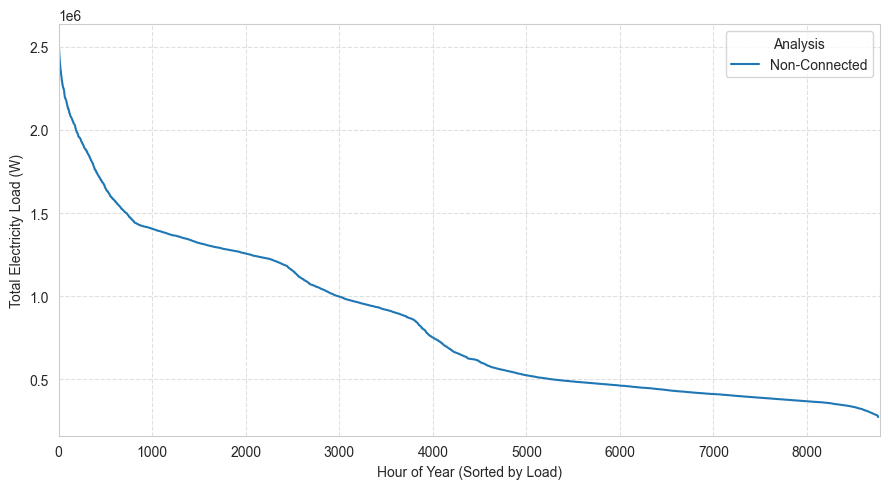

Saved load_duration_curve_total_electricity_first100.png


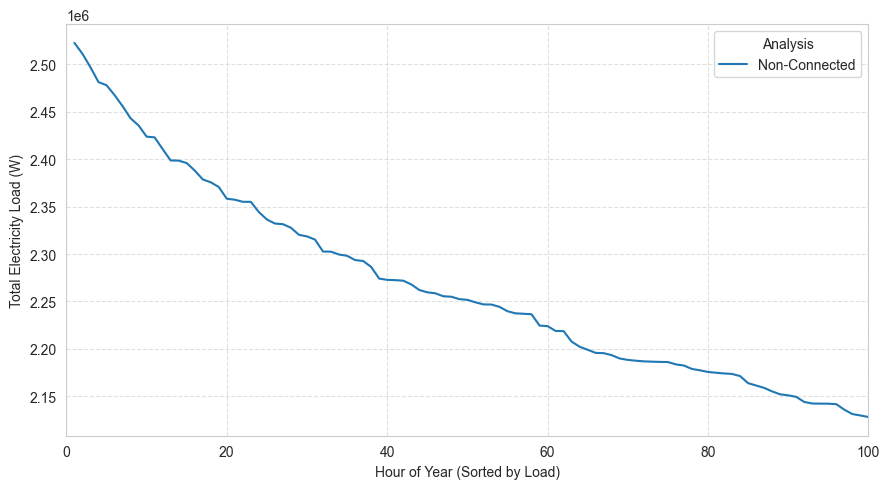

Processing LDC for       Hour Rank      Load (W)       Analysis
0             1  5.523951e+06  Non-Connected
1             2  5.457578e+06  Non-Connected
2             3  5.374470e+06  Non-Connected
3             4  5.326204e+06  Non-Connected
4             5  5.258057e+06  Non-Connected
...         ...           ...            ...
8755       8756  1.057694e+05  Non-Connected
8756       8757  1.050901e+05  Non-Connected
8757       8758  1.042191e+05  Non-Connected
8758       8759  1.040123e+05  Non-Connected
8759       8760  1.031962e+05  Non-Connected

[8760 rows x 3 columns]
Processing LDC 100 for     Hour Rank      Load (W)       Analysis
0           1  5.523951e+06  Non-Connected
1           2  5.457578e+06  Non-Connected
2           3  5.374470e+06  Non-Connected
3           4  5.326204e+06  Non-Connected
4           5  5.258057e+06  Non-Connected
..        ...           ...            ...
95         96  3.586989e+06  Non-Connected
96         97  3.583595e+06  Non-Connected
97    

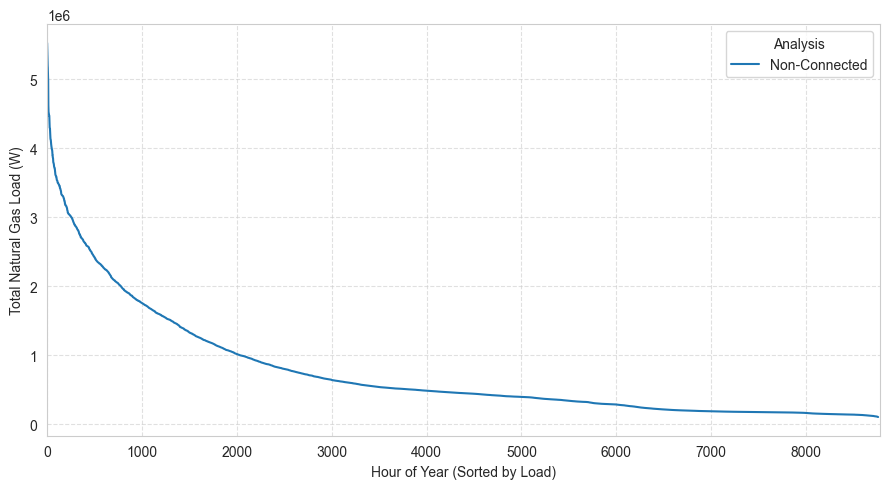

Saved load_duration_curve_total_natural_gas_first100.png


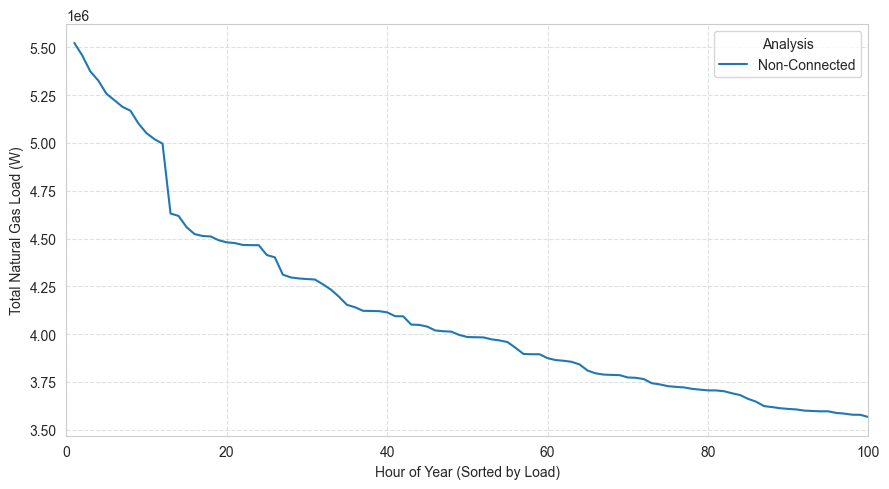

Processing LDC for       Hour Rank      Load (W)       Analysis
0             1  7.284339e+06  Non-Connected
1             2  7.254351e+06  Non-Connected
2             3  6.965902e+06  Non-Connected
3             4  6.929040e+06  Non-Connected
4             5  6.908196e+06  Non-Connected
...         ...           ...            ...
8755       8756  4.028494e+05  Non-Connected
8756       8757  4.020456e+05  Non-Connected
8757       8758  3.998156e+05  Non-Connected
8758       8759  3.988950e+05  Non-Connected
8759       8760  3.836932e+05  Non-Connected

[8760 rows x 3 columns]
Processing LDC 100 for     Hour Rank      Load (W)       Analysis
0           1  7.284339e+06  Non-Connected
1           2  7.254351e+06  Non-Connected
2           3  6.965902e+06  Non-Connected
3           4  6.929040e+06  Non-Connected
4           5  6.908196e+06  Non-Connected
..        ...           ...            ...
95         96  4.927212e+06  Non-Connected
96         97  4.923615e+06  Non-Connected
97    

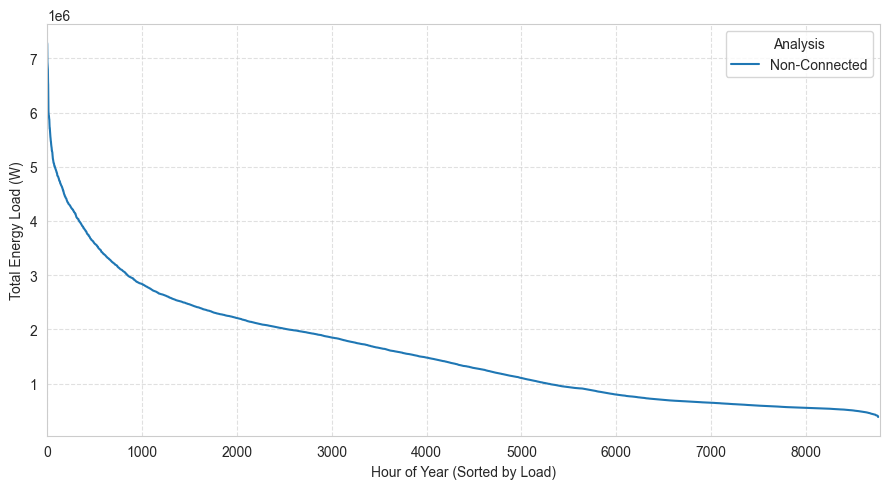

Saved load_duration_curve_total_energy_first100.png


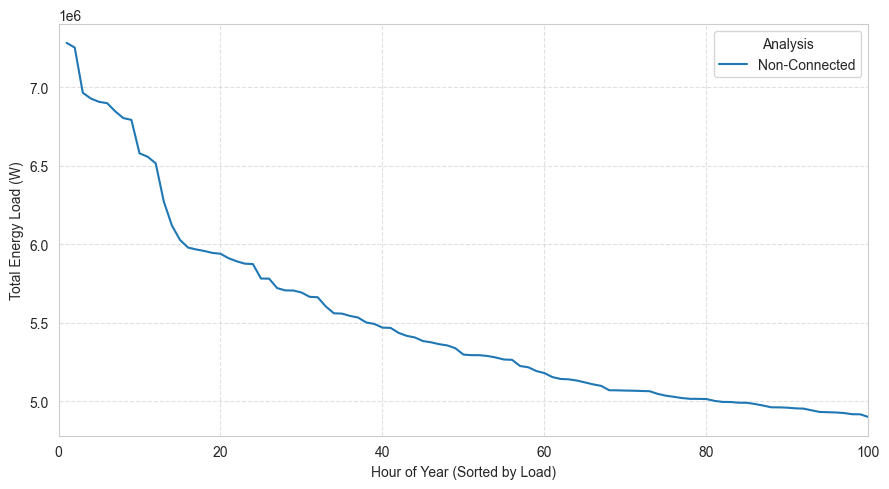

In [11]:
## Plotting load duration curves for Total Electricity and Total Natural Gas
# Note that Total Natural Gas does not include the DES boiler at the moment...

# Load Duration Curves (LDCs)
ldc_vars = ["Total Electricity", "Total Natural Gas", "Total Energy"]

for ldc_var in ldc_vars:
    combined_ldc_df = []  # To hold LDC data from all scenarios
    combined_ldc_df_100 = []  # To hold LDC data from all scenarios

    for analysis_name in ["Non-Connected", *list(uo_analysis.modelica.keys())]:
        if analysis_name == "Non-Connected":
            df_15min = uo_analysis.urbanopt.data_15min[ldc_var].copy()
            df_hourly = df_15min.resample("H").max()  # Resample to hourly max
            display_name = "Non-Connected"
        else:
            df_15min = (
                uo_analysis.modelica[analysis_name]
                .min_15_with_buildings[ldc_var]
                .copy()
            )
            df_hourly = df_15min.resample("H").max()  # Resample to hourly max
            display_name = uo_analysis.modelica[analysis_name].display_name

        # Sort hourly load descending for LDC
        ldc_series = df_hourly.sort_values(ascending=False).reset_index(drop=True)
        ldc_df = pd.DataFrame(
            {
                "Hour Rank": range(1, len(ldc_series) + 1),
                "Load (W)": ldc_series,
                "Analysis": display_name,
            }
        )
        combined_ldc_df.append(ldc_df)
        combined_ldc_df_100.append(ldc_df.head(100))

    combined_ldc_df = pd.concat(combined_ldc_df)
    combined_ldc_df_100 = pd.concat(combined_ldc_df_100)
    print(f"Processing LDC for {combined_ldc_df}")
    print(f"Processing LDC 100 for {combined_ldc_df_100}")

    # Plot LDC
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.lineplot(
        data=combined_ldc_df, x="Hour Rank", y="Load (W)", hue="Analysis", ax=ax
    )
    ax.set_ylabel(f"{ldc_var} Load (W)")
    ax.set_xlabel("Hour of Year (Sorted by Load)")
    ax.set_xlim(0, len(ldc_series) + 20)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    # Save with appropriate filename
    filename = f"load_duration_curve_{ldc_var.lower().replace(' ', '_')}.png"
    plt.savefig(results_summary_dir / filename, dpi=300)
    print(f"Saved {filename}")
    plt.show()

    # zoom into the first 100 hours and plot
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.lineplot(
        data=combined_ldc_df_100, x="Hour Rank", y="Load (W)", hue="Analysis", ax=ax
    )
    ax.set_ylabel(f"{ldc_var} Load (W)")
    ax.set_xlabel("Hour of Year (Sorted by Load)")
    ax.set_xlim(0, 100)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    # Save zoomed plot with appropriate filename
    filename = f"load_duration_curve_{ldc_var.lower().replace(' ', '_')}_first100.png"
    plt.savefig(results_summary_dir / filename, dpi=300)
    print(f"Saved {filename}")
    plt.show()